In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
import seaborn as sns

# データ分割
from sklearn.model_selection import train_test_split

# 線形モデル
from sklearn.ensemble import RandomForestClassifier

# グラフをアウトプット行に出力するためのマジックコマンド
%matplotlib inline

# 精度評価
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from lazypredict.Supervised import LazyClassifier 
import lightgbm as lgb
import optuna

In [2]:
train = pd.read_csv('../../data/processed/train_age_flag_encoded.csv')
test = pd.read_csv('../../data/processed/test_age_flag_encoded.csv')

In [3]:
# 説明変数と目的変数に分割

# 説明変数
X = train.drop(['Exited'],axis=1)
# 目的変数
y = train['Exited']

In [4]:
# データの分割
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state=42,
                                                    stratify=y)
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (11250, 853), X_test: (3750, 853)


## 複数のモデルでROCを比較

In [5]:
clf = LazyClassifier(ignore_warnings=True, predictions=True)   #設定
models, predictions = clf.fit(X_train, X_test, y_train, y_test) #実行

High-dimensional dataset (853 features). Some models may be slow or fail. Consider dimensionality reduction.


In [6]:
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
BernoulliNB,0.872800,0.844756,0.916355,0.877229,0.885736,0.872800,1.906709
NearestCentroid,0.849333,0.844113,0.917503,0.857959,0.879388,0.849333,2.143578
LGBMClassifier,0.898400,0.825352,0.930281,0.896412,0.895455,0.898400,2.349711
LinearDiscriminantAnalysis,0.897067,0.824515,0.926197,0.895196,0.894216,0.897067,6.282758
LinearSVC,0.894933,0.819772,0.924460,0.892848,0.891812,0.894933,4.890583
AdaBoostClassifier,0.900000,0.818094,0.929324,0.896881,0.896290,0.900000,8.712039
LogisticRegression,0.892267,0.814694,0.913043,0.890007,0.888906,0.892267,2.099354
RandomForestClassifier,0.898933,0.810618,0.929281,0.895033,0.894901,0.898933,10.512843
CalibratedClassifierCV,0.898133,0.806713,0.925464,0.893845,0.893983,0.898133,13.819223


## LightGBMを用いてモデルを作成する

In [7]:
dtrain = lgb.Dataset(X_train, y_train)
dvalid = lgb.Dataset(X_test, y_test)

params = {
    'objective': 'binary',
    'metrics': 'auc',
    'boosting_type': 'gbdt',
    'verbosity': -1,
    'learning_rate': 0.01   
}

model = lgb.train(params, dtrain, num_boost_round=1000)
pred_prob = model.predict(X_test)

## Optunaを用いてhyper parameterのチューニングを行う

In [8]:
# 目的関数の定義
def objective(trial):
    dtrain = lgb.Dataset(X_train, y_train)
    dvalid = lgb.Dataset(X_test, y_test)

    params = {
        'objective': 'binary',
        'metrics': 'auc',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'lambda_l1'         : trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2'         : trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0),
        'num_leaves': trial.suggest_int('num_leaves', 2, 256),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),

        'force_col_wise':True,
        'random_state': 0,
    }

    model = lgb.train(
        params=params,
        train_set=dtrain,
        num_boost_round=100,
    )

    pred = model.predict(X_test, num_iteration=model.best_iteration)
    score = roc_auc_score(y_test, pred)
    
    return score

In [9]:
# 最適化の実行
optuna.logging.disable_default_handler()
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42), )
study.optimize(objective, n_trials=60)

In [10]:
# 最も精度の高いパラメータ
print('＝＝＝＝ベストパラメーター＝＝＝＝＝')
print(study.best_params)

# 最も精度の高いパラメータで学習を再度実行
best_params = {
        'objective': 'binary',
        'metrics': 'auc',
        'boosting_type': 'gbdt',
        'verbosity': -1
    }
best_params.update(study.best_params)

＝＝＝＝ベストパラメーター＝＝＝＝＝
{'lambda_l1': 8.953823670172653, 'lambda_l2': 2.9977842675809767, 'learning_rate': 0.10341456871123794, 'num_leaves': 173, 'feature_fraction': 0.40958136401793205, 'bagging_fraction': 0.9789894601749595, 'bagging_freq': 4, 'min_child_samples': 77}


## 層化K分割を用いてクロスバリデーションを行い、モデルの性能を評価する

In [11]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=43)
valid_score = []

for fold, (train_index, valid_index) in enumerate(skf.split(X, y)):
    X_tr, X_va = X.iloc[train_index], X.iloc[valid_index]
    y_tr, y_va = y.iloc[train_index], y.iloc[valid_index]
    set_tr = lgb.Dataset(X_tr, y_tr)
    
    model_tmp = lgb.train(
        params = best_params,
        train_set = set_tr
    )

    pred = model_tmp.predict(X_va)
    roc_score = roc_auc_score(y_va, pred)
    valid_score.append(roc_score)

    print(f'fold:{fold + 1} roc_score: {roc_score}')

cv_score = np.mean(valid_score)
print(f'cv_score: {cv_score}')

fold:1 roc_score: 0.9349354342518693
fold:2 roc_score: 0.9373101208657666
fold:3 roc_score: 0.9366022651383279
fold:4 roc_score: 0.9322237549402788
fold:5 roc_score: 0.9322826003656627
cv_score: 0.934670835112381


In [12]:
best_model = lgb.train(
    params = best_params,
    train_set = dtrain
)

pd.DataFrame(best_model.feature_importance(), index=X_train.columns )

,0
CreditScore,238
Age,226
Tenure,107
Balance,206
EstimatedSalary,217
...,...
NumOfProducts_1.0,23
NumOfProducts_2.0,36
NumOfProducts_3.0,24
NumOfProducts_4.0,0


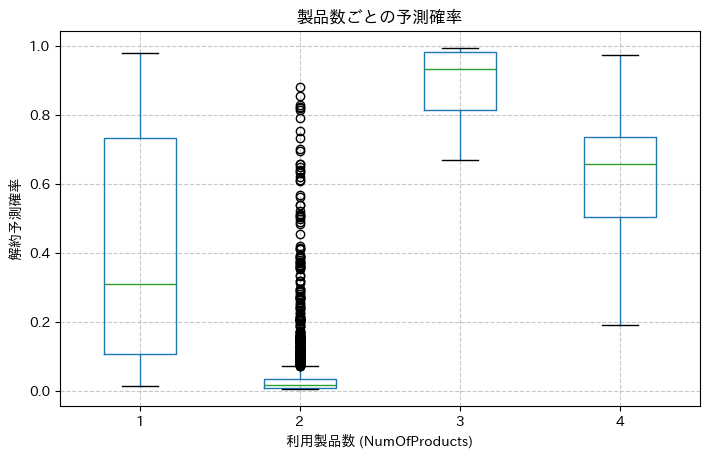

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. テストデータに対する予測確率を取得
y_test_proba = best_model.predict(X_test)

# 2. X_testのコピーを作成し、予測確率を追加
X_test_check = X_test.copy()
X_test_check['pred_proba'] = y_test_proba

# --------------------------------------------------
# 【修正】'2.0' のような小数点文字列を安全に整数に変換する
# --------------------------------------------------
# 列名に 'NumOfProducts_' が含まれる列（ダミー変数）を自動で全取得
products_columns = [col for col in X_test_check.columns if 'NumOfProducts_' in str(col)]

# 1が入っている列名を探し、数値を復元
X_test_check['NumOfProducts'] = (
    X_test_check[products_columns]
    .idxmax(axis=1)
    .astype(str)
    .str.replace('NumOfProducts_', '')
    .astype(float)  # 【重要】先に '2.0' を 2.0 (float型) に変換
    .astype(int)    # そのあと 2.0 を 2 (int型) に変換
)
# --------------------------------------------------

# 3. 製品数ごとの予測確率の分布を描画
X_test_check.boxplot(column='pred_proba', by='NumOfProducts', figsize=(8, 5))
plt.title('製品数ごとの予測確率')
plt.xlabel('利用製品数 (NumOfProducts)')
plt.ylabel('解約予測確率')
plt.suptitle('') 
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 学習済みモデルを用いてテストデータを予測

In [14]:
# 1. 欠損値を埋める
test_encoded = test.fillna(0)

# 2. 提出用の「確率」を予測する (predict ではなく predict_proba)
# ※学習時と同じ列にするため、もし 'id' や 'Exited' が残っていれば drop してください
X_test_final = test_encoded.drop(columns=['id', 'Exited'], errors='ignore')
pred_proba = best_model.predict(X_test_final)

In [15]:
np.savetxt('../../model/pred_test_proba_age_flag.txt', pred_proba)

print("予測確率の保存が完了しました。左のフォルダから 'pred_test_proba_age_flag.txt' をダウンロードするか、次のファイルで読み込んでください。")

予測確率の保存が完了しました。左のフォルダから 'pred_test_proba_age_flag.txt' をダウンロードするか、次のファイルで読み込んでください。
